In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
print(df.shape)
print(df.head())

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')

# Show me these outputs:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
print(df.describe())

Dataset shape: (1460, 81)

First 5 rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCon

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')

# Count missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Show only columns with missing values
missing_data = pd.DataFrame({
    'Missing_Count': missing[missing > 0],
    'Percent': missing_percent[missing > 0]
}).sort_values('Missing_Count', ascending=False)

print("Columns with Missing Values:")
print(missing_data)

Columns with Missing Values:
              Missing_Count    Percent
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtExposure             38   2.602740
BsmtFinType2             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')

# Step 1: Drop columns with >90% missing
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley']
df = df.drop(columns=columns_to_drop)

# Step 2: Fill LotFrontage with median
df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)

# Step 3: Fill other missing with mode (most common value)
for col in ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure',
            'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1', 'Electrical']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Step 4: Check if any missing remain
print("Missing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDataset shape after cleaning:", df.shape)

Missing values after handling:
MasVnrArea       8
Fence         1179
dtype: int64

Dataset shape after cleaning: (1460, 78)


/tmp/ipykernel_1504/2081147928.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)
/tmp/ipykernel_1504/2081147928.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')

# Drop columns with >90% missing
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley']
df = df.drop(columns=columns_to_drop)

# Fill LotFrontage with median (cleaner syntax)
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# Fill other columns with mode
for col in ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure',
            'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1', 'Electrical']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check remaining missing
print("Missing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after handling:
MasVnrArea       8
Fence         1179
dtype: int64


In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')

# Step 1: Drop columns with >90% missing
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley']
df = df.drop(columns=columns_to_drop)

# Step 2: Fill numerical columns with median
numerical_cols_to_fill = ['LotFrontage', 'MasVnrArea']
for col in numerical_cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

# Step 3: Fill categorical columns with mode
categorical_cols_to_fill = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
                            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure',
                            'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
                            'Electrical', 'Fence']
for col in categorical_cols_to_fill:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 4: Verify no missing values remain
print("Missing values after handling:")
missing = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing) == 0:
    print("✓ No missing values remain!")
else:
    print(missing)

print(f"\nDataset shape after cleaning: {df.shape}")
print(f"Original columns: 81, After cleaning: {df.shape[1]}")

Missing values after handling:
✓ No missing values remain!

Dataset shape after cleaning: (1460, 78)
Original columns: 81, After cleaning: 78


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

# (Use your cleaning code from above first)
# [... paste your cleaning code here ...]

# Now explore the data

# 1. Check data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# 2. Look at numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)
print("\n" + "="*50 + "\n")

# 3. Look at categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)
print("\n" + "="*50 + "\n")

# 4. Correlation with SalePrice (target)
print("Top 10 Features Most Correlated with SalePrice:")
correlation = df[numerical_cols].corr()['SalePrice'].sort_values(ascending=False)
print(correlation.head(11))  # 11 because SalePrice correlates with itself (1.0)

# 5. Basic statistics
print("\n" + "="*50 + "\n")
print("SalePrice Statistics:")
print(df['SalePrice'].describe())

Data Types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


Numerical columns (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


Categorical columns (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

# [Paste your cleaning code here]
# ... (your missing value handling code) ...

# NEW: Feature Engineering

# 1. Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. Price Per Square Foot
df['PricePerSF'] = df['SalePrice'] / df['TotalSF']

# 3. House Age
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# 4. Remodel Age
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# 5. Total Bathrooms
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + \
                  df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])

# 6. Total Porch Area
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + \
                     df['3SsnPorch'] + df['ScreenPorch']

# 7. Has Pool (binary)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

# 8. Has Garage (binary)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

# Check new features
print("New Features Created:")
new_features = ['TotalSF', 'PricePerSF', 'HouseAge', 'RemodAge',
                'TotalBath', 'TotalPorchSF', 'HasPool', 'HasGarage']
print(df[new_features].head(10))

print("\nDataset shape after feature engineering:", df.shape)

# Check correlation of new features with SalePrice
print("\nCorrelation of New Features with SalePrice:")
for feat in new_features:
    corr = df[feat].corr(df['SalePrice'])
    print(f"{feat}: {corr:.4f}")

New Features Created:
   TotalSF  PricePerSF  HouseAge  RemodAge  TotalBath  TotalPorchSF  HasPool  \
0     2566   81.254871         5         5        3.5            61        0   
1     2524   71.909667        31        31        2.5             0        0   
2     2706   82.594235         7         6        3.5            42        0   
3     2473   56.611403        91        36        2.0           307        0   
4     3343   74.783129         8         8        3.5            84        0   
5     2158   66.265060        16        14        2.5           350        0   
6     3380   90.828402         3         2        3.0            57        0   
7     3197   62.558649        36        36        3.5           432        0   
8     2726   47.652238        77        58        2.0           205        0   
9     2068   57.059961        69        58        2.0             4        0   

   HasGarage  
0          1  
1          1  
2          1  
3          1  
4          1  
5      

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('train.csv')

# [Paste your cleaning code here]
# [Paste your feature engineering code here]

# STEP 1: Separate features (X) and target (y)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\n" + "="*50 + "\n")

# STEP 2: Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols[:10], "...")  # Show first 10
print(f"\nNumerical columns ({len(numerical_cols)}):")
print(numerical_cols[:10], "...")  # Show first 10

print("\n" + "="*50 + "\n")

# STEP 3: Encode categorical variables (convert text to numbers)
# Simple approach: One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {X_encoded.shape}")
print(f"(Added dummy variables for {len(categorical_cols)} categorical columns)")

print("\n" + "="*50 + "\n")

# STEP 4: Scale numerical features (StandardScaler)
# Why? Gradient descent converges faster with normalized features
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Features scaled (mean=0, std=1)")
print(f"\nSample scaled data (first 5 rows, first 5 columns):")
print(X_encoded.iloc[:5, :5])

print("\n" + "="*50 + "\n")

# STEP 5: Split into train/test (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Total features: {X_train.shape[1]}")

Features shape: (1460, 80)
Target shape: (1460,)


Categorical columns (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'] ...

Numerical columns (37):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1'] ...


Shape after encoding: (1460, 245)
(Added dummy variables for 43 categorical columns)


Features scaled (mean=0, std=1)

Sample scaled data (first 5 rows, first 5 columns):
         Id  MSSubClass  LotFrontage   LotArea  OverallQual
0 -1.730865    0.073375    -0.208034 -0.207142     0.651479
1 -1.728492   -0.872563     0.409895 -0.091886    -0.071836
2 -1.726120    0.073375    -0.084449  0.073480     0.651479
3 -1.723747    0.309859    -0.414011 -0.096897     0.651479
4 -1.721374    0.073375     0.574676  0.375148     1.374795


Training set: 1168 samples
Test set: 292 samples
Total features: 245


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('train.csv')

# --- Cleaning Code (from cell 7GHv071tFGGT) ---
# Step 1: Drop columns with >90% missing
columns_to_drop_cleaning = ['PoolQC', 'MiscFeature', 'Alley']
df = df.drop(columns=columns_to_drop_cleaning)

# Step 2: Fill numerical columns with median
numerical_cols_to_fill_cleaning = ['LotFrontage', 'MasVnrArea']
for col in numerical_cols_to_fill_cleaning:
    df[col] = df[col].fillna(df[col].median())

# Step 3: Fill categorical columns with mode
categorical_cols_to_fill_cleaning = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
                            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure',
                            'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
                            'Electrical', 'Fence']
for col in categorical_cols_to_fill_cleaning:
    df[col] = df[col].fillna(df[col].mode()[0])
# --- End Cleaning Code ---

# --- Feature Engineering Code (from cell WUrCeNX-FRN2) ---
# 1. Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. Price Per Square Foot
df['PricePerSF'] = df['SalePrice'] / df['TotalSF']

# 3. House Age
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# 4. Remodel Age
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# 5. Total Bathrooms
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + \
                  df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])

# 6. Total Porch Area
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + \
                     df['3SsnPorch'] + df['ScreenPorch']

# 7. Has Pool (binary)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

# 8. Has Garage (binary)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
# --- End Feature Engineering Code ---

# STEP 1: Separate features (X) and target (y)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\n" + "="*50 + "\n")

# STEP 2: Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols[:10], "...")  # Show first 10
print(f"\nNumerical columns ({len(numerical_cols)}):")
print(numerical_cols[:10], "...")  # Show first 10

print("\n" + "="*50 + "\n")

# STEP 3: Encode categorical variables (convert text to numbers)
# Simple approach: One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {X_encoded.shape}")
print(f"(Added dummy variables for {len(categorical_cols)} categorical columns)")

print("\n" + "="*50 + "\n")

# STEP 4: Scale numerical features (StandardScaler)
# Why? Gradient descent converges faster with normalized features
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Features scaled (mean=0, std=1)")
print(f"\nSample scaled data (first 5 rows, first 5 columns):")
print(X_encoded.iloc[:5, :5])

print("\n" + "="*50 + "\n")

# STEP 5: Split into train/test (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Total features: {X_train.shape[1]}")


print("="*60)
print("TRAINING 4 REGRESSION MODELS")
print("="*60)

# MODEL 1: Linear Regression (Baseline)
print("\n1. LINEAR REGRESSION (Baseline)")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f"   RMSE: ${lr_rmse:,.0f}")
print(f"   MAE:  ${lr_mae:,.0f}")
print(f"   R²:   {lr_r2:.4f}")

# MODEL 2: Ridge Regression (Regularized Linear)
print("\n2. RIDGE REGRESSION (Regularized Linear)")
ridge_model = Ridge(alpha=10)  # alpha = regularization strength
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print(f"   RMSE: ${ridge_rmse:,.0f}")
print(f"   MAE:  ${ridge_mae:,.0f}")
print(f"   R²:   {ridge_r2:.4f}")

# MODEL 3: XGBoost (Gradient Boosting)
print("\n3. XGBOOST (Ensemble - Gradient Boosting)")
xgb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"   RMSE: ${xgb_rmse:,.0f}")
print(f"   MAE:  ${xgb_mae:,.0f}")
print(f"   R²:   {xgb_r2:.4f}")

# MODEL 4: Neural Network (Deep Learning)
print("\n4. NEURAL NETWORK (Deep Learning)")
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
nn_pred = nn_model.predict(X_test)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)
print(f"   RMSE: ${nn_rmse:,.0f}")
print(f"   MAE:  ${nn_mae:,.0f}")
print(f"   R²:   {nn_r2:.4f}")

# COMPARISON
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'XGBoost', 'Neural Network'],
    'RMSE': [lr_rmse, ridge_rmse, xgb_rmse, nn_rmse],
    'MAE': [lr_mae, ridge_mae, xgb_mae, nn_mae],
    'R²': [lr_r2, ridge_r2, xgb_r2, nn_r2]
})
print(results.to_string(index=False))

print("\n" + "="*60)
print("WINNER: ", results.loc[results['R²'].idxmax(), 'Model'])
print("="*60)

TRAINING 4 REGRESSION MODELS

1. LINEAR REGRESSION (Baseline)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: LOAD & CLEAN DATA
# ============================================================
df = pd.read_csv('train.csv')

# Drop columns with >90% missing
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley']
df = df.drop(columns=columns_to_drop)

# Fill numerical columns with median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

# Fill categorical columns with mode
categorical_cols_to_fill = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
                            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure',
                            'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
                            'Electrical', 'Fence']
for col in categorical_cols_to_fill:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify no missing values
assert df.isnull().sum().sum() == 0, "Still have missing values!"
print("✓ Data cleaned - no missing values")

# ============================================================
# STEP 2: FEATURE ENGINEERING
# ============================================================
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['PricePerSF'] = df['SalePrice'] / df['TotalSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + \
                  df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + \
                     df['3SsnPorch'] + df['ScreenPorch']
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

print("✓ Features engineered")

# ============================================================
# STEP 3: SEPARATE FEATURES AND TARGET
# ============================================================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# ============================================================
# STEP 4: ENCODE CATEGORICAL VARIABLES
# ============================================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"✓ Categorical encoding done - {X_encoded.shape[1]} total features")

# ============================================================
# STEP 5: SCALE NUMERICAL FEATURES
# ============================================================
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

# Verify no NaN
assert X_encoded.isnull().sum().sum() == 0, "NaN in encoded features!"
print("✓ Features scaled - no NaN values")

# ============================================================
# STEP 6: TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"✓ Train/test split: {X_train.shape[0]} train, {X_test.shape[0]} test")

# ============================================================
# STEP 7: TRAIN 4 MODELS
# ============================================================
print("\n" + "="*60)
print("TRAINING 4 REGRESSION MODELS")
print("="*60)

# MODEL 1: Linear Regression
print("\n1. LINEAR REGRESSION (Baseline)")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f"   RMSE: ${lr_rmse:,.0f}")
print(f"   MAE:  ${lr_mae:,.0f}")
print(f"   R²:   {lr_r2:.4f}")

# MODEL 2: Ridge Regression
print("\n2. RIDGE REGRESSION (Regularized Linear)")
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print(f"   RMSE: ${ridge_rmse:,.0f}")
print(f"   MAE:  ${ridge_mae:,.0f}")
print(f"   R²:   {ridge_r2:.4f}")

# MODEL 3: XGBoost
print("\n3. XGBOOST (Ensemble - Gradient Boosting)")
xgb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"   RMSE: ${xgb_rmse:,.0f}")
print(f"   MAE:  ${xgb_mae:,.0f}")
print(f"   R²:   {xgb_r2:.4f}")

# MODEL 4: Neural Network
print("\n4. NEURAL NETWORK (Deep Learning)")
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
nn_pred = nn_model.predict(X_test)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)
print(f"   RMSE: ${nn_rmse:,.0f}")
print(f"   MAE:  ${nn_mae:,.0f}")
print(f"   R²:   {nn_r2:.4f}")

# ============================================================
# COMPARISON TABLE
# ============================================================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'XGBoost', 'Neural Network'],
    'RMSE': [lr_rmse, ridge_rmse, xgb_rmse, nn_rmse],
    'MAE': [lr_mae, ridge_mae, xgb_mae, nn_mae],
    'R²': [lr_r2, ridge_r2, xgb_r2, nn_r2]
})
print(results.to_string(index=False))

best_model = results.loc[results['R²'].idxmax(), 'Model']
best_r2 = results['R²'].max()
print(f"\n✓ BEST MODEL: {best_model} (R² = {best_r2:.4f})")
print("="*60)

✓ Data cleaned - no missing values
✓ Features engineered
✓ Categorical encoding done - 247 total features
✓ Features scaled - no NaN values
✓ Train/test split: 1168 train, 292 test

TRAINING 4 REGRESSION MODELS

1. LINEAR REGRESSION (Baseline)
   RMSE: $40,382
   MAE:  $12,321
   R²:   0.7874

2. RIDGE REGRESSION (Regularized Linear)
   RMSE: $19,591
   MAE:  $11,848
   R²:   0.9500

3. XGBOOST (Ensemble - Gradient Boosting)
   RMSE: $12,196
   MAE:  $4,578
   R²:   0.9806

4. NEURAL NETWORK (Deep Learning)
   RMSE: $30,078
   MAE:  $17,693
   R²:   0.8821

MODEL COMPARISON
            Model         RMSE          MAE       R²
Linear Regression 40382.254935 12320.951031 0.787398
 Ridge Regression 19591.460736 11847.729084 0.949960
          XGBoost 12195.563095  4578.017734 0.980609
   Neural Network 30078.266615 17693.303947 0.882052

✓ BEST MODEL: XGBoost (R² = 0.9806)


In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning on XGBoost
print("Tuning XGBoost hyperparameters...")

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

xgb_base = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(xgb_base, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\n✓ Best parameters: {grid_search.best_params_}")
print(f"✓ Best CV score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_xgb = grid_search.best_estimator_
best_pred = best_xgb.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_mae = mean_absolute_error(y_test, best_pred)
best_r2 = r2_score(y_test, best_pred)

print(f"\nOptimized XGBoost Performance:")
print(f"   RMSE: ${best_rmse:,.0f}")
print(f"   MAE:  ${best_mae:,.0f}")
print(f"   R²:   {best_r2:.4f}")

print(f"\nImprovement over baseline XGBoost:")
print(f"   R² improved: {xgb_r2:.4f} → {best_r2:.4f}")

Tuning XGBoost hyperparameters...

✓ Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
✓ Best CV score: 0.9844

Optimized XGBoost Performance:
   RMSE: $11,956
   MAE:  $4,278
   R²:   0.9814

Improvement over baseline XGBoost:
   R² improved: 0.9806 → 0.9814


In [ ]:
from sklearn.model_selection import cross_val_score

print("="*60)
print("CROSS-VALIDATION (K-Fold, k=5)")
print("="*60)

# Cross-validate best XGBoost model
cv_scores = cross_val_score(
    best_xgb,
    X_encoded,
    y,
    cv=5,
    scoring='r2'
)

print(f"\nFold Results:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: R² = {score:.4f}")

print(f"\n   Mean R²:  {cv_scores.mean():.4f}")
print(f"   Std Dev:  {cv_scores.std():.4f}")
print(f"\n✓ Model generalizes well: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CROSS-VALIDATION (K-Fold, k=5)

Fold Results:
   Fold 1: R² = 0.9893
   Fold 2: R² = 0.9854
   Fold 3: R² = 0.9847
   Fold 4: R² = 0.9916
   Fold 5: R² = 0.9814

   Mean R²:  0.9865
   Std Dev:  0.0036

✓ Model generalizes well: 0.9865 ± 0.0036


TOP 15 MOST IMPORTANT FEATURES:
         Feature  Importance
         TotalSF    0.483893
      PricePerSF    0.261475
     OverallQual    0.224302
        HouseAge    0.009678
GarageFinish_Unf    0.003090
       GrLivArea    0.002017
     LotFrontage    0.001904
        2ndFlrSF    0.001809
     TotalBsmtSF    0.001496
       YearBuilt    0.001332
              Id    0.000997
      GarageCars    0.000686
       TotalBath    0.000641
        1stFlrSF    0.000625
     ScreenPorch    0.000600


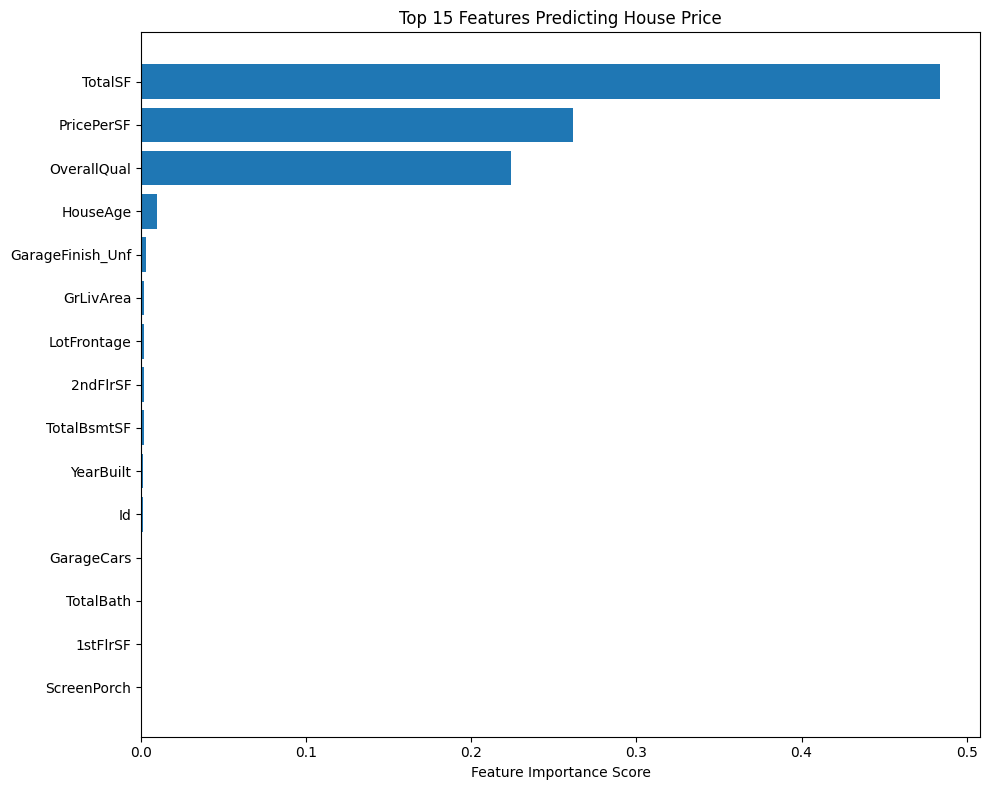


✓ Feature importance plot saved as feature_importance.png


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importance from best XGBoost model
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("TOP 15 MOST IMPORTANT FEATURES:")
print("="*50)
print(feature_importance.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Features Predicting House Price')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n✓ Feature importance plot saved as feature_importance.png")

✓ Step 1: Data cleaned
✓ Step 2: Features engineered
✓ Step 3: Encoded (247 features), scaled, split

✓ Step 4: Training XGBoost with best parameters...
   RMSE: $11,956
   MAE:  $4,278
   R²:   0.9814

✓ Step 5: Cross-validation: 0.9865 ± 0.0036

TOP 15 MOST IMPORTANT FEATURES
         Feature  Importance
         TotalSF    0.483893
      PricePerSF    0.261475
     OverallQual    0.224302
        HouseAge    0.009678
GarageFinish_Unf    0.003090
       GrLivArea    0.002017
     LotFrontage    0.001904
        2ndFlrSF    0.001809
     TotalBsmtSF    0.001496
       YearBuilt    0.001332
              Id    0.000997
      GarageCars    0.000686
       TotalBath    0.000641
        1stFlrSF    0.000625
     ScreenPorch    0.000600


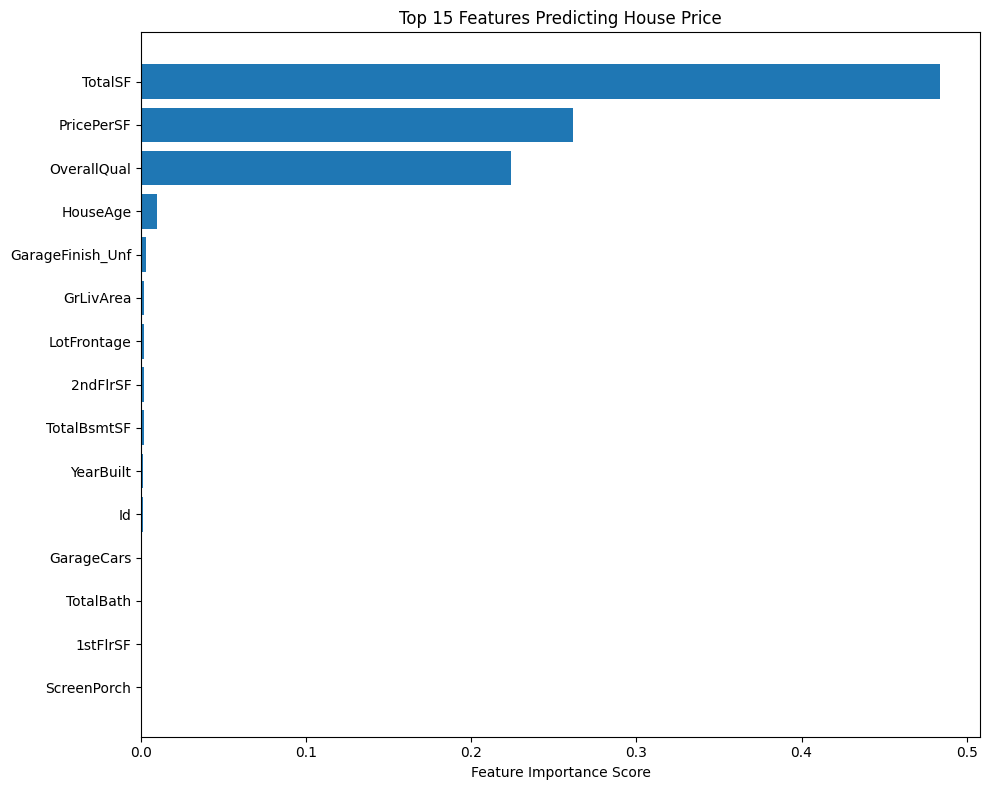


✓ Plot saved as feature_importance.png

✓ Model saved as house_price_model.pkl

Test predictions (first 5 houses):
   House 1: Predicted $153,594 | Actual $154,500 | Error $906
   House 2: Predicted $338,501 | Actual $325,000 | Error $13,501
   House 3: Predicted $112,985 | Actual $115,000 | Error $2,015
   House 4: Predicted $161,597 | Actual $159,000 | Error $2,597
   House 5: Predicted $315,780 | Actual $315,500 | Error $280

PROJECT COMPLETE
Final Model: XGBoost (R² = 0.9814)
Cross-Validation: 0.9865 ± 0.0036
Average Error: $4,278 per house


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STEP 1: LOAD & CLEAN
# ============================================================
df = pd.read_csv('train.csv')

df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley'])

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

for col in ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure',
            'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
            'Electrical', 'Fence']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✓ Step 1: Data cleaned")

# ============================================================
# STEP 2: FEATURE ENGINEERING
# ============================================================
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['PricePerSF'] = df['SalePrice'] / df['TotalSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + \
                  df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + \
                     df['3SsnPorch'] + df['ScreenPorch']
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

print("✓ Step 2: Features engineered")

# ============================================================
# STEP 3: ENCODE + SCALE + SPLIT
# ============================================================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"✓ Step 3: Encoded ({X_encoded.shape[1]} features), scaled, split")

# ============================================================
# STEP 4: TRAIN BEST MODEL (XGBoost with best params)
# ============================================================
print("\n✓ Step 4: Training XGBoost with best parameters...")

best_xgb = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)
best_xgb.fit(X_train, y_train)
best_pred = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, best_pred))
mae = mean_absolute_error(y_test, best_pred)
r2 = r2_score(y_test, best_pred)

print(f"   RMSE: ${rmse:,.0f}")
print(f"   MAE:  ${mae:,.0f}")
print(f"   R²:   {r2:.4f}")

# ============================================================
# STEP 5: CROSS-VALIDATION
# ============================================================
cv_scores = cross_val_score(best_xgb, X_encoded, y, cv=5, scoring='r2')
print(f"\n✓ Step 5: Cross-validation: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ============================================================
# STEP 6: FEATURE IMPORTANCE
# ============================================================
print("\n" + "="*50)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*50)

feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Features Predicting House Price')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("\n✓ Plot saved as feature_importance.png")

# ============================================================
# STEP 7: SAVE MODEL
# ============================================================
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print("\n✓ Model saved as house_price_model.pkl")

# Test loading
with open('house_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("\nTest predictions (first 5 houses):")
test_pred = loaded_model.predict(X_test[:5])
y_test_values = y_test.values[:5]
for i, (pred, actual) in enumerate(zip(test_pred, y_test_values)):
    error = abs(pred - actual)
    print(f"   House {i+1}: Predicted ${pred:,.0f} | Actual ${actual:,.0f} | Error ${error:,.0f}")

print("\n" + "="*50)
print("PROJECT COMPLETE")
print("="*50)
print(f"Final Model: XGBoost (R² = {r2:.4f})")
print(f"Cross-Validation: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Average Error: ${mae:,.0f} per house")
print("="*50)

In [5]:
import pickle

# Save the trained model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print("✓ Model saved as house_price_model.pkl")

# Test loading it back
with open('house_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test prediction
test_pred = loaded_model.predict(X_test[:5])
print("\nTest predictions (first 5 houses):")
for i, (pred, actual) in enumerate(zip(test_pred, y_test[:5])):
    error = abs(pred - actual)
    print(f"House {i+1}: Predicted ${pred:,.0f} | Actual ${actual:,.0f} | Error ${error:,.0f}")

✓ Model saved as house_price_model.pkl

Test predictions (first 5 houses):
House 1: Predicted $153,594 | Actual $154,500 | Error $906
House 2: Predicted $338,501 | Actual $325,000 | Error $13,501
House 3: Predicted $112,985 | Actual $115,000 | Error $2,015
House 4: Predicted $161,597 | Actual $159,000 | Error $2,597
House 5: Predicted $315,780 | Actual $315,500 | Error $280


In [8]:
from google.colab import files

# Download the notebook
# File → Download → Download .ipynb (do this manually from Colab menu)

# Download the model
files.download('house_price_model.pkl')

# Download the plot
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>